**IMDB — blank run**

Integer reviews in, a vibe out. Load the built-in bag of word ids, fix the lengths, embed and flatten, dense stack, train, score it, peek at a few calls, plot how the run felt.

In [9]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, Flatten, Dropout

In [2]:
# Load dataset
vocab_size = 10000

(x_train, y_train) , (x_test, y_test) = imdb.load_data(num_words=vocab_size)
print("Training samples:", len(x_train))
print("Testing samples :", len(x_test))

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


/Users/froncort.ai/Desktop/LP_5/lp5/venv/lib/python3.12/site-packages/numpy/lib/_format_impl.py:838: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  array = pickle.load(fp, **pickle_kwargs)


Training samples: 25000
Testing samples : 25000


In [3]:
# Pad sequences
max_length = 200

x_train = pad_sequences(x_train, maxlen=max_length)
x_test = pad_sequences(x_test, maxlen=max_length)

In [4]:
# Model & compile
model = Sequential()
model.add(Embedding(input_dim=vocab_size, output_dim=32, input_length=vocab_size))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(1, activation= 'sigmoid'))

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


/Users/froncort.ai/Desktop/LP_5/lp5/venv/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [5]:
# Train
# ── Step 5: Train ────────────────────────────────────────────────────────────
# batch_size=128: larger batches = faster training for this size dataset
# validation_split=0.2: 20% of training data used to monitor generalisation
history = model.fit(
    x_train, y_train,
    epochs=5,
    batch_size=128,
    validation_split=0.2
)

Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6485 - loss: 0.5944 - val_accuracy: 0.7730 - val_loss: 0.4999
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9000 - loss: 0.2591 - val_accuracy: 0.8664 - val_loss: 0.3227
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9738 - loss: 0.0795 - val_accuracy: 0.8544 - val_loss: 0.4711
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9936 - loss: 0.0219 - val_accuracy: 0.8556 - val_loss: 0.6322
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9975 - loss: 0.0087 - val_accuracy: 0.8498 - val_loss: 0.7788


In [6]:
# Evaluate
loss, accuracy = model.evaluate(x_test, y_test)
print(f"Test Loss     : {loss:.4f}")
print(f"Test Accuracy : {accuracy:.4f}")

782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 607us/step - accuracy: 0.8456 - loss: 0.7965
Test Loss     : 0.7965
Test Accuracy : 0.8456


In [7]:
# Sample predictions
predictions = model.predict(x_test[:5])

print("Sample Predictions:")
for i, pred in enumerate(predictions):
    sentiment = "Positive" if pred > 0.5 else "Negative"
    print(f"  Review {i+1}: {sentiment}  (score: {pred[0]:.4f})")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Sample Predictions:
  Review 1: Negative  (score: 0.0283)
  Review 2: Positive  (score: 1.0000)
  Review 3: Positive  (score: 0.9993)
  Review 4: Negative  (score: 0.1874)
  Review 5: Positive  (score: 1.0000)


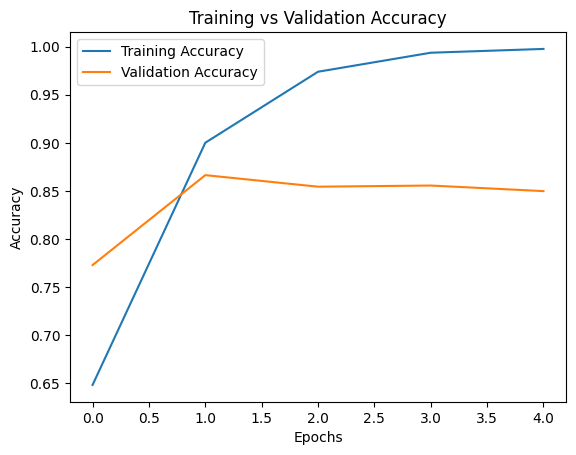

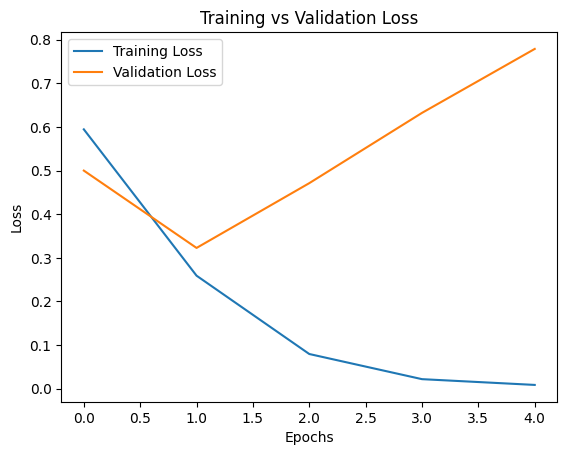

In [10]:
# Plot
# ── Step 8: Plot Training Curves ─────────────────────────────────────────────
# A good model: both train & val accuracy go up and stay close together
plt.plot(history.history['accuracy'],     label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()

plt.plot(history.history['loss'],     label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()